<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [42]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [43]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [44]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [45]:
df = pd.read_csv('/content/foodhub_order.csv')
df

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31


In [46]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data?

In [47]:
# returns the number of rows and columns in the dataset
df.shape

(1898, 9)

#### Observations: The dataset contains 1,898 rows and 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used)

In [48]:
# shows data types and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: The dataset contains a mix of numerical and categorical variables. All columns appear to have complete non-null entries.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method.

In [49]:
# checks for missing values in each column
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations: There are no missing values in the dataset.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [50]:
# summary statistics for preparation time
df['food_preparation_time'].describe()

,food_preparation_time
count,1898.000000
mean,27.371970
std,4.632481
min,20.000000
25%,23.000000
50%,27.000000
75%,31.000000
max,35.000000


#### Observations: Food preparation time varies within a reasonable range. The average provides insight into typical kitchen performance. Max at 35 could be due to non typical understaff


### **Question 5:** How many orders are not rated?

In [51]:
# counts orders without ratings
df['rating'].isnull().sum()

np.int64(0)

#### Observations: The number of unrated orders indicates how many customers did not leave feedback. This could impact the analysis of customer satisfaction


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.)

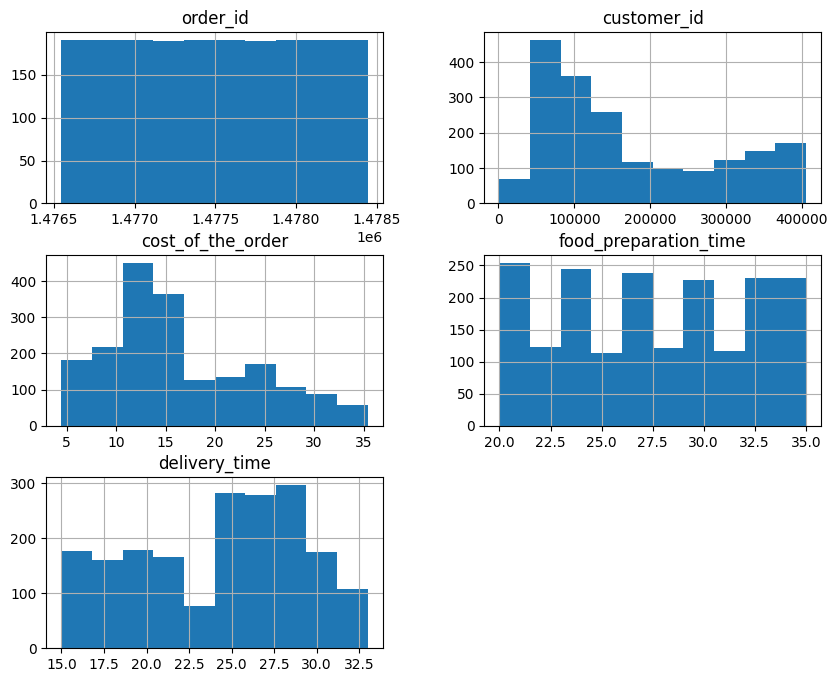

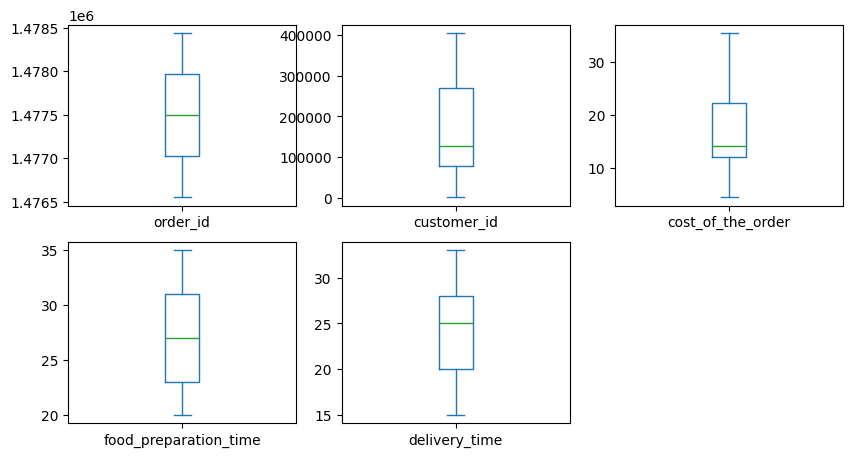

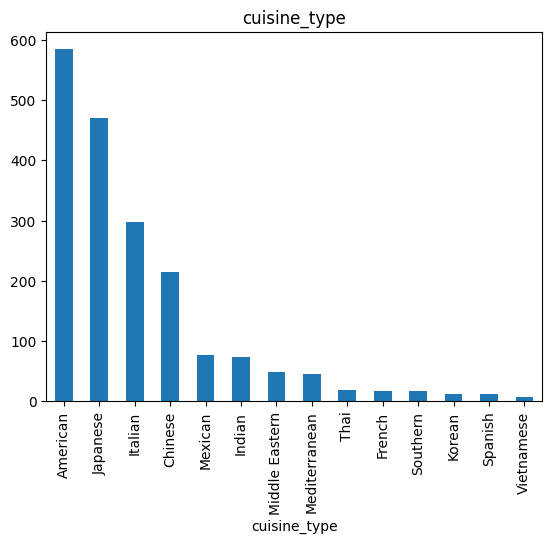

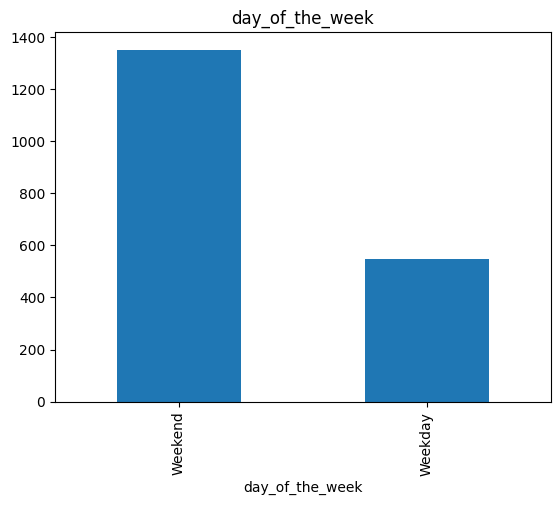

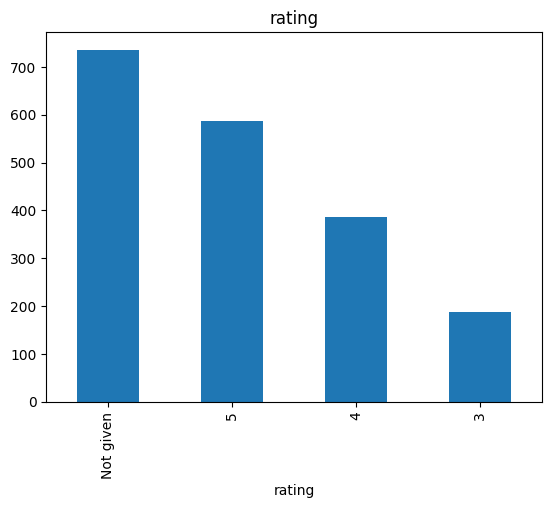

In [52]:
# histograms for all numeric variables
df.hist(figsize=(10,8))
# boxplots for numeric variables
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(10,8))
for col in df.select_dtypes(include='object').columns:
  df[col].value_counts().plot(kind='bar')
  plt.title(col)
  plt.show()

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

In [53]:
# top 5 restaurants by number of orders
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations: Shake Shack dominates order volume, suggesting strong customer preference or higher visibility


### **Question 8**: Which is the most popular cuisine on weekends?

In [54]:
# most popular weekend cuisine
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations: American is the most popular cuisine on the weekend. This could be due to more time availability and the desire for leisure food.






### **Question 9**: What percentage of the orders cost more than 20 dollars?

In [55]:
# percentage of orders above $20
round((df[df['cost_of_the_order'] > 20].shape[0] / df.shape[0]) * 100, 2)

29.24

#### Observations: This isn't accurate to the current economy. This dataset must be dominated by solo dining


### **Question 10**: What is the mean order delivery time?

In [56]:
# average delivery time
round(df['delivery_time'].mean(), 2)

np.float64(24.16)

 The average delivery time provides a baseline for service performance and customer expectation.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed.

In [57]:
# top 3 customers by order count
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations: These customers contributes significantly to total orders, indicating high-value repeat customers.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)


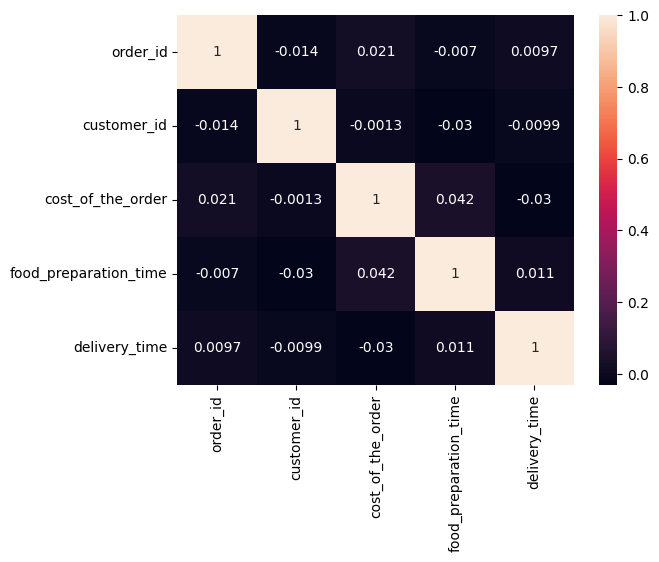

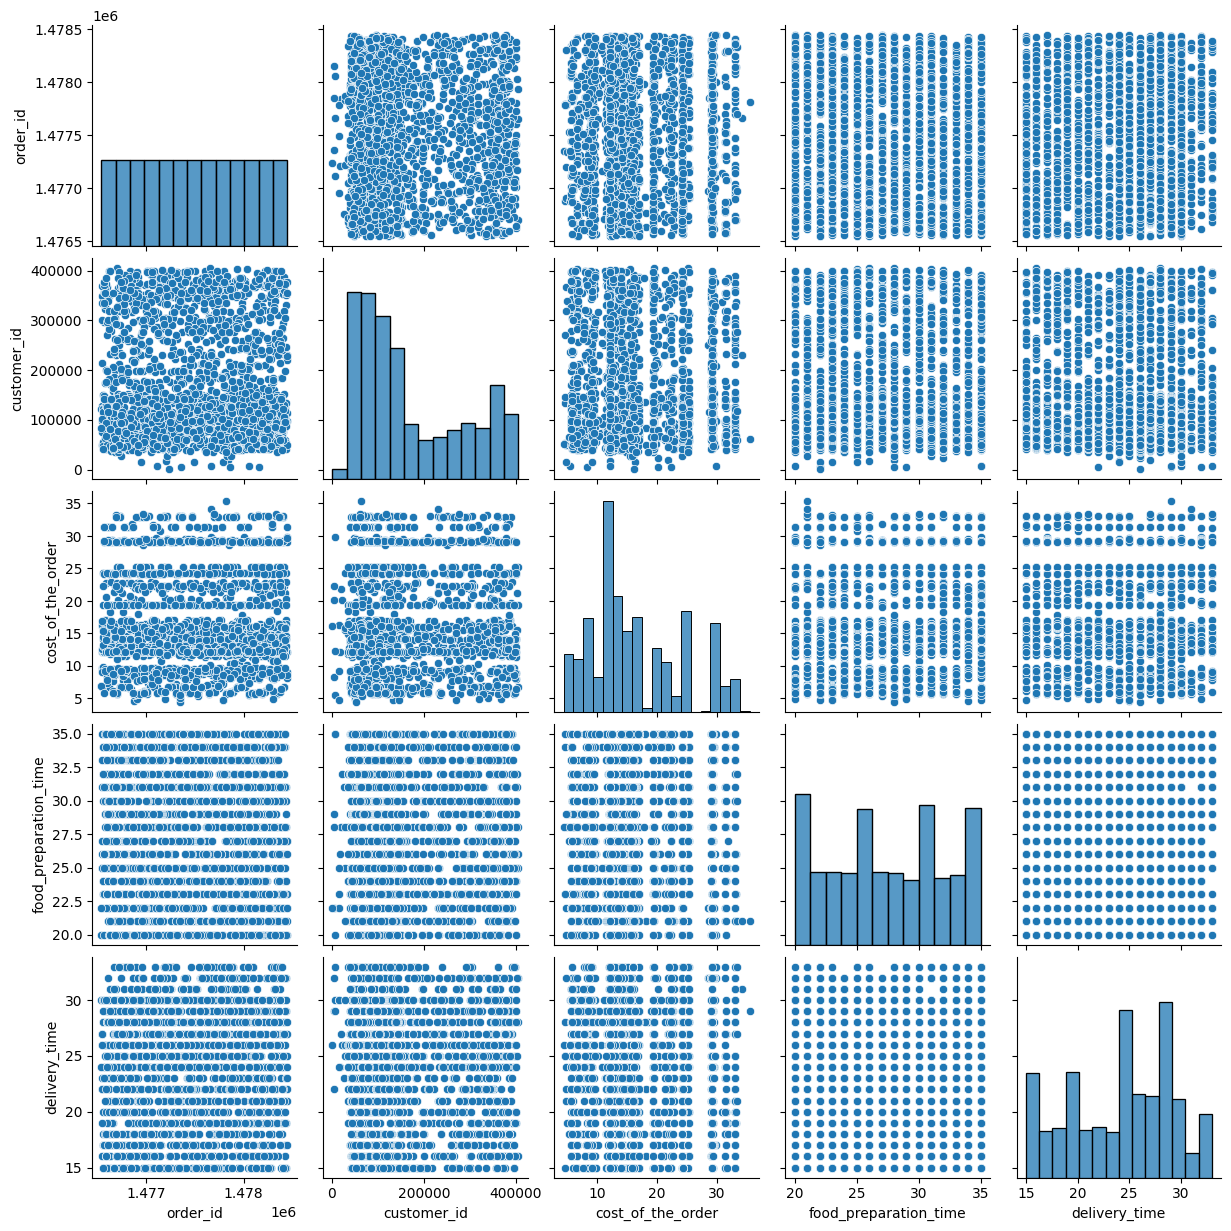

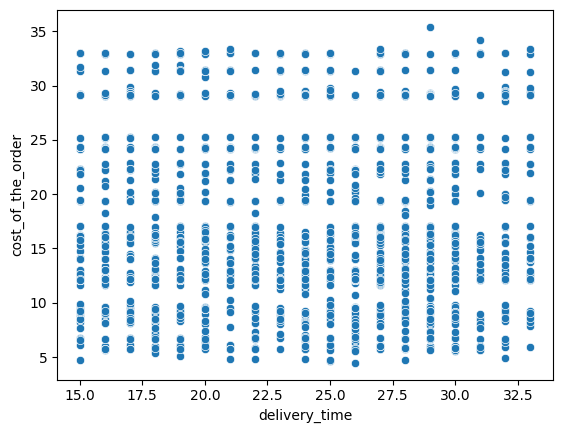

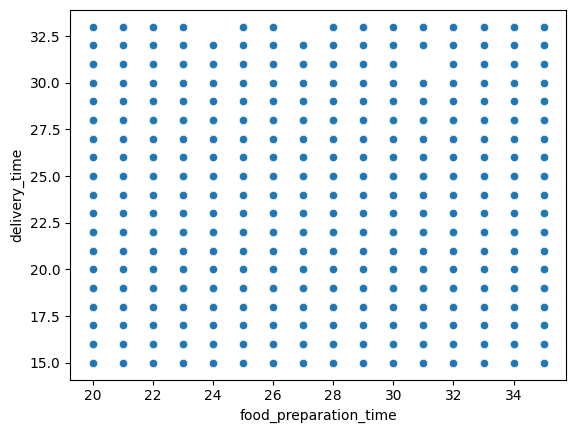

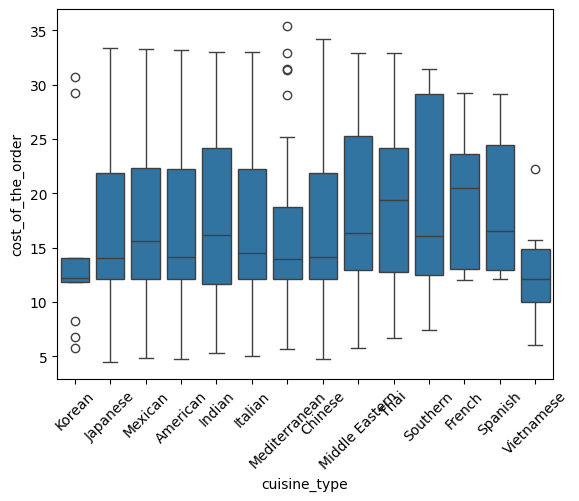

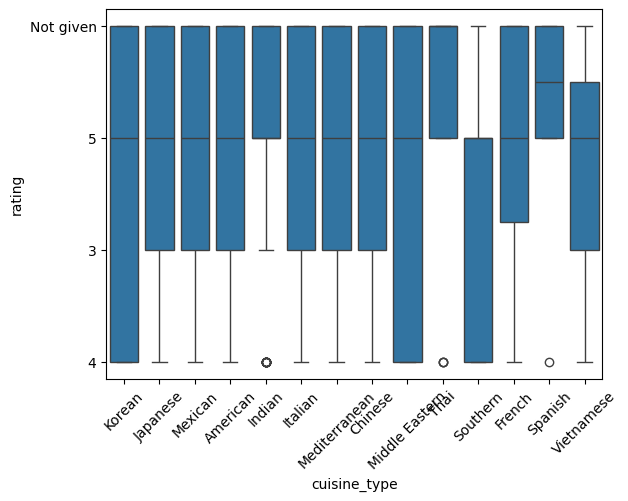

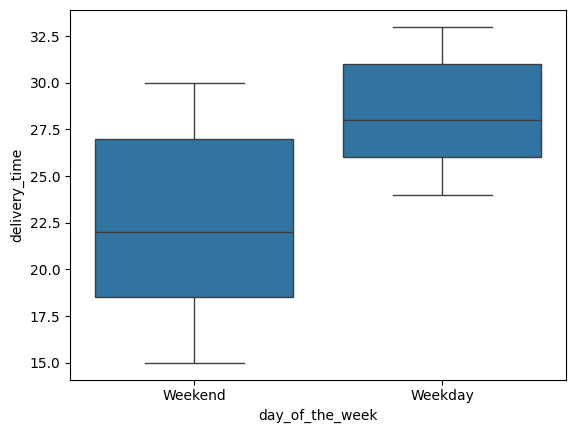

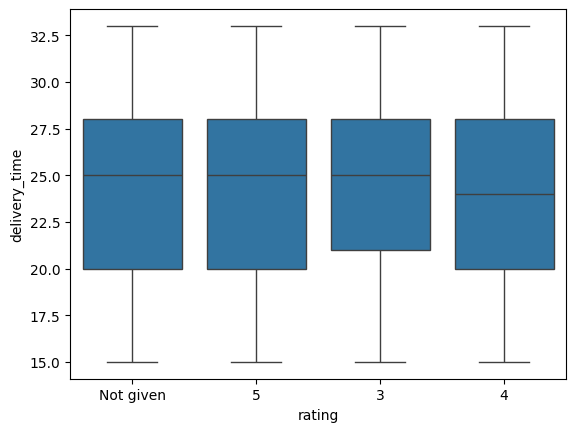

In [58]:
sns.heatmap(df.corr(numeric_only=True), annot=True) # correlation between numeric variables
plt.show()
sns.pairplot(df.select_dtypes(include='number')) # relationships across all numeric variables
plt.show()
sns.scatterplot(x='delivery_time', y='cost_of_the_order', data=df) # cost vs delivery
plt.show()
sns.scatterplot(x='food_preparation_time', y='delivery_time', data=df) # prep vs delivery
plt.show()
sns.boxplot(x='cuisine_type', y='cost_of_the_order', data=df) # cuisine vs cost
plt.xticks(rotation=45)
plt.show()
sns.boxplot(x='cuisine_type', y='rating', data=df) # cuisine vs rating
plt.xticks(rotation=45)
plt.show()
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df) # weekday vs delivery
plt.show()
sns.boxplot(x='rating', y='delivery_time', data=df)
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

In [59]:
# criteria qualifying restaurants
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])\
  .query('count > 50 and mean > 4')

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations: Only a subset of restaurants meet both high rating count and high average rating, indicating consistently strong performers. We knew from question 7 that Shake Shack would have a high count. This also highlights the large amount of customers that don't submit rating.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [60]:
# total revenue
revenue = (df[df['cost_of_the_order'] > 20]['cost_of_the_order'] * 0.25).sum() + \
          (df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]['cost_of_the_order'] * 0.15).sum()
revenue

np.float64(6166.303)

#### Observations: Higher-cost orders contribute more per transaction, but mid-range orders also significantly impact total revenue due to volume.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.)

In [61]:
# total time per order
total_time = df['food_preparation_time'] + df['delivery_time']
# % over 60 mins
round((total_time[total_time > 60].count() / total_time.count()) * 100, 2)

np.float64(10.54)

#### Observations: There is a decently small percentage of orders exceed 60 minutes, which may negatively impact customer satisfaction and should be monitored.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [62]:
# classify day
df['day_type'] = df['day_of_the_week'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
# compare delivery times
df.groupby('day_type')['delivery_time'].mean()

,delivery_time
day_type,
Weekday,24.161749


#### Observations: Delivery times may differ between weekdays and weekends, potentially due to higher demand or operational constraints.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.)

### Conclusions:

* Order demand is concentrated among a small number of restaurants and customers, indicating uneven distribution of activity on the platform.

* Delivery time is closely influenced by food preparation time, making kitchen efficiency a key driver of overall service performance.

* Popular cuisines, particularly American, dominate order volume, especially during weekends.

* Most orders fall within a mid-range cost, but higher-value orders contribute disproportionately to revenue.

* A portion of orders experience longer delivery times, which may negatively impact customer satisfaction and ratings.

### Recommendations:

* Improve operational efficiency by reducing food preparation and delivery times to enhance customer satisfaction.

* Strengthen partnerships with high-performing restaurants that have both high ratings and high order volumes.

* Focus marketing efforts on popular cuisines (such as American) during peak periods, especially weekends, to maximize demand.

* Implement targeted loyalty programs or incentives for frequent customers to increase retention and lifetime value.

* Encourage more customers to provide ratings to improve data quality and better assess restaurant performance.

* Monitor and optimize delivery operations during high-demand periods (weekends) to reduce delays and maintain service quality.

---